In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# Load Dataset
df = pd.read_csv('Bank_Churn.csv')
df.head(5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 1) What is the total number of rows and columns in the dataset, and what are their respective data types?

In [82]:
rows, columns = df.shape

print('Total rows = ',rows)
print('Total Columns = ',columns)

print('\nColumns DataTypes:')
print(df.dtypes)

Total rows =  10000
Total Columns =  13

Columns DataTypes:
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


### 2) Are there any missing or null values in the dataset? If yes, count them per column.

In [83]:
missing_values = df.isnull().sum()
print("Missing/Null Values per columns:")
print(missing_values)

Missing/Null Values per columns:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


### 3) Check for any duplicate records in the dataset and clean them if necessary.

In [84]:
print("Duplicate resords: ",df.duplicated().sum())

Duplicate resords:  0


### 4) Generate descriptive statistics (mean, median, standard deviation, min, max) for all numerical features.

In [85]:
numerical_stats = df.select_dtypes(include='number').agg(
    ['mean', 'median', 'std', 'min', 'max']
)

print(numerical_stats)

          CustomerId  CreditScore        Age     Tenure        Balance  \
mean    1.569094e+07   650.528800  38.921800   5.012800   76485.889288   
median  1.569074e+07   652.000000  37.000000   5.000000   97198.540000   
std     7.193619e+04    96.653299  10.487806   2.892174   62397.405202   
min     1.556570e+07   350.000000  18.000000   0.000000       0.000000   
max     1.581569e+07   850.000000  92.000000  10.000000  250898.090000   

        NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary    Exited  
mean         1.530200    0.70550        0.515100    100090.239881  0.203700  
median       1.000000    1.00000        1.000000    100193.915000  0.000000  
std          0.581654    0.45584        0.499797     57510.492818  0.402769  
min          1.000000    0.00000        0.000000        11.580000  0.000000  
max          4.000000    1.00000        1.000000    199992.480000  1.000000  


### 5) Identify the unique categories and their frequencies in the categorical columns (Geography and Gender).

In [86]:
print("Geography:")
geography_counts = df['Geography'].value_counts()
print(geography_counts)

print('\nGender:')
gender_counts = df['Gender'].value_counts()
print(gender_counts)

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


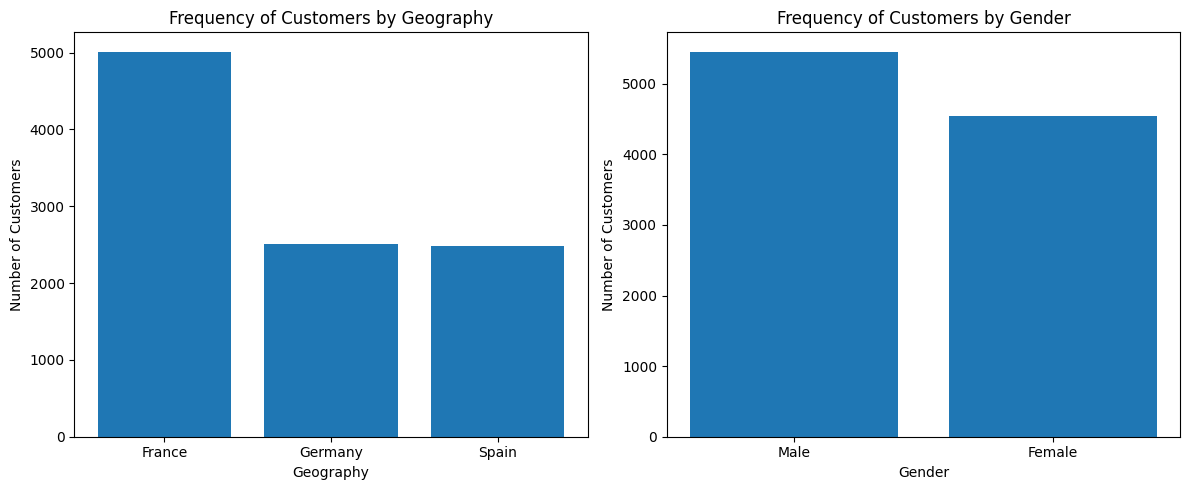

In [87]:
# Create visualization
plt.figure(figsize=(12, 5))

# Geography
plt.subplot(1, 2, 1)
plt.bar(geography_counts.index, geography_counts.values)
plt.title('Frequency of Customers by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')

# Gender
plt.subplot(1, 2, 2)
plt.bar(gender_counts.index, gender_counts.values)
plt.title('Frequency of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

## Employee/Customer Attrition & Churn Analysis

### 6) Calculate the overall Churn Rate (percentage of individuals who exited).

In [88]:
churned = (df['Exited'] == 1).sum()
total = len(df)

churn_rate = (churned / total) * 100

print(f"Total Individuals: {total}")
print(f"Total Exited: {churned}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Individuals: 10000
Total Exited: 2037
Overall Churn Rate: 20.37%


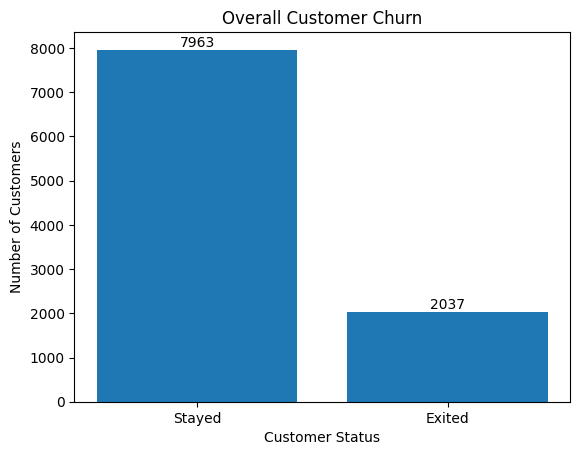

In [89]:
# Calculate churn counts
churn_counts = df['Exited'].value_counts()

# Create labels
labels = ['Stayed', 'Exited']

plt.bar(labels, churn_counts.sort_index())
plt.title('Overall Customer Churn')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

# Display values on bars
for i, value in enumerate(churn_counts.sort_index()):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

### 7) Calculate and compare the Churn Rate across genders (Female vs Male).

In [90]:
churn_by_gender = (
    df.groupby('Gender')['Exited']
      .mean()
      .mul(100)
      .round(2)
)

for gender, rate in churn_by_gender.items():
    print(f"{gender}: {rate}%")

Female: 25.07%
Male: 16.46%


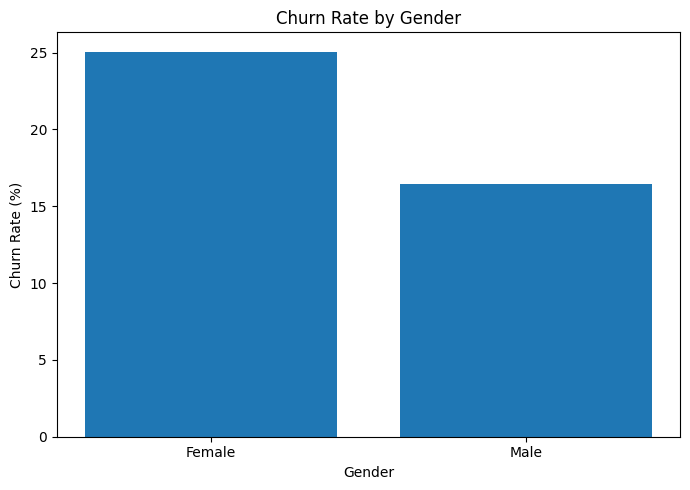

In [91]:
# Visualization
plt.figure(figsize=(7, 5))

bars = plt.bar(churn_by_gender.index, churn_by_gender.values)

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### 8) Analyze the Churn Rate and total exited count broken down by Geography.

In [92]:
total_customers = df.groupby('Geography')['Exited'].count()
exited_customers = df.groupby('Geography')['Exited'].sum()
churn_rate = (exited_customers / total_customers) *100

geography_analysis = pd.DataFrame({
    'Total Customers': total_customers,
    'Total Exited':exited_customers,
    'Churn Rate (%)':churn_rate.round(2)
})

print(geography_analysis)


           Total Customers  Total Exited  Churn Rate (%)
Geography                                               
France                5014           810           16.15
Germany               2509           814           32.44
Spain                 2477           413           16.67


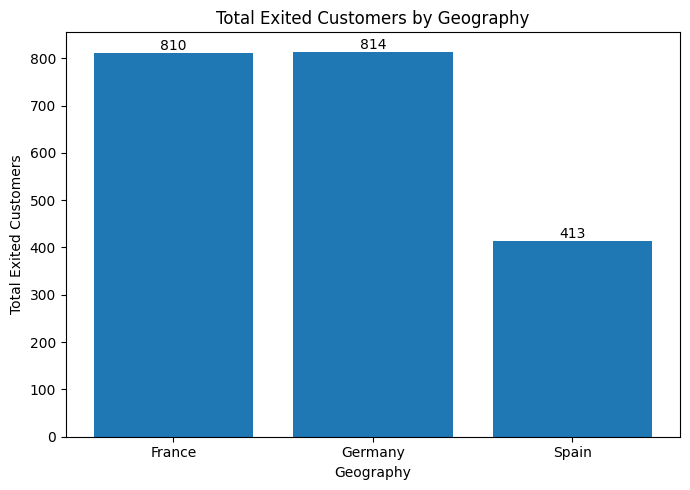

In [93]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    geography_analysis.index,
    geography_analysis['Total Exited']
)

plt.title('Total Exited Customers by Geography')
plt.xlabel('Geography')
plt.ylabel('Total Exited Customers')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### 9) What is the distribution of age among churned vs non-churned individuals? Which age group experiences the highest churn?

In [94]:
# Create age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate churn rate by age group
age_churn = df.groupby('Age_Group', observed=True)['Exited'].agg(
    Total='count',
    Exited='sum',
    Churn_Rate='mean'
)

age_churn['Churn_Rate'] = age_churn['Churn_Rate'] * 100

print(age_churn.round(2))

           Total  Exited  Churn_Rate
Age_Group                           
18-25        611      46        7.53
26-35       3542     301        8.50
36-45       3736     733       19.62
46-55       1311     663       50.57
56-65        536     259       48.32
66+          264      35       13.26


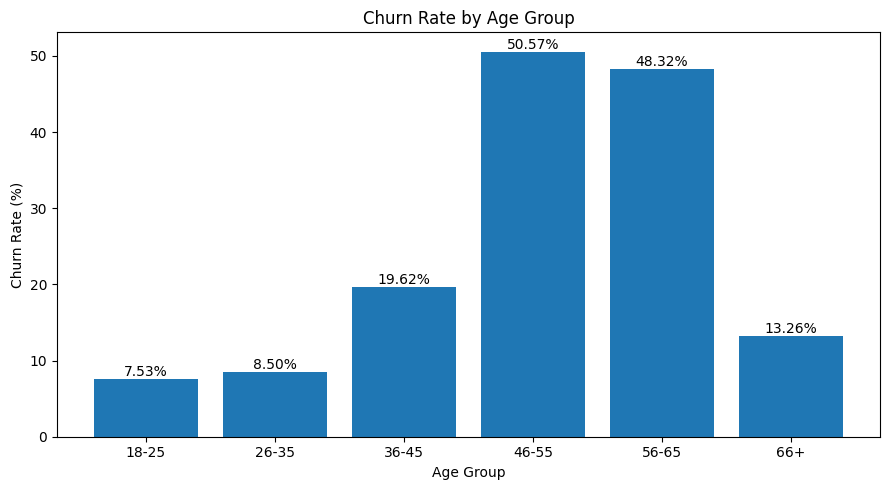

In [95]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_churn.index.astype(str),
    age_churn['Churn_Rate']
)

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

for bar, value in zip(bars, age_churn['Churn_Rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### 10) Is there a significant difference in Churn Rate between active members (IsActiveMember = 1) and inactive members (IsActiveMember = 0)?

In [96]:
import pandas as pd

# Churn rate by active member status
churn_by_activity = df.groupby('IsActiveMember')['Exited'].mean() * 100

print("Churn Rate:")
print(churn_by_activity.round(2))

Churn Rate:
IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


In [97]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    df['IsActiveMember'],
    df['Exited']
)

print("Contingency Table:")
print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("P-value:", p_value)

# Significance decision
if p_value < 0.05:
    print("There is a statistically significant difference in churn rates.")
else:
    print("There is no statistically significant difference in churn rates.")

Contingency Table:
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735

Chi-Square Statistic: 242.98534164287963
P-value: 8.785858269303705e-55
There is a statistically significant difference in churn rates.


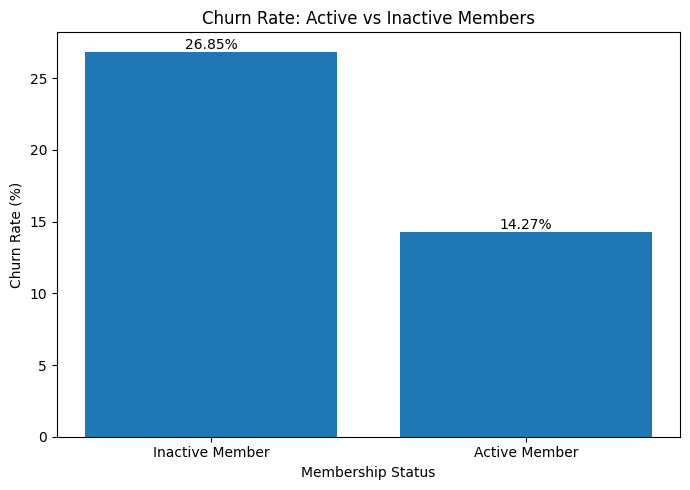

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Inactive Member', 'Active Member'],
    churn_by_activity.values
)

plt.title('Churn Rate: Active vs Inactive Members')
plt.xlabel('Membership Status')
plt.ylabel('Churn Rate (%)')

for bar, value in zip(bars, churn_by_activity.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## Financial & Performance Metrics Analysis

### 11) Compare the average account balance of individuals who left (Exited = 1) versus those who stayed (Exited = 0).

In [99]:
churned_balance = df.loc[df['Exited'] == 1, 'Balance'].mean()
stayed_balance = df.loc[df['Exited'] == 0, 'Balance'].mean()

print(f"Average Balance - Churned: {churned_balance:.2f}")
print(f"Average Balance - Stayed: {stayed_balance:.2f}")

print(f"Difference: {abs(churned_balance - stayed_balance):.2f}")

Average Balance - Churned: 91108.54
Average Balance - Stayed: 72745.30
Difference: 18363.24


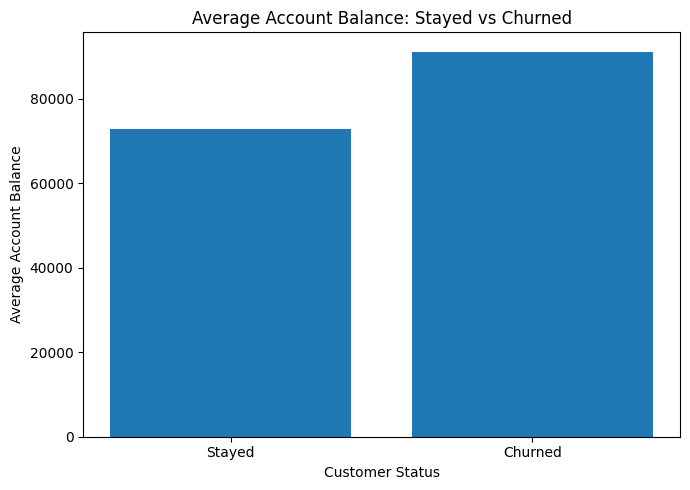

In [100]:
labels = ['Stayed', 'Churned']
values = [stayed_balance, churned_balance]
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values)
plt.title('Average Account Balance: Stayed vs Churned')
plt.xlabel('Customer Status')
plt.ylabel('Average Account Balance')
plt.tight_layout()
plt.show()

### 12) Group EstimatedSalary into salary slabs/brackets and analyze if salary level impacts the Churn Rate.

In [101]:
print("Salary min:", df['EstimatedSalary'].min())
print("Salary max:", df['EstimatedSalary'].max())

# Define salary brackets (e.g., 0-50k, 50k-100k, 100k-150k, 150k-200k+)
bins = [0, 50000, 100000, 150000, 200000]
labels = ['Low (< $50k)', 'Medium ($50k - $100k)', 'High ($100k - $150k)', 'Very High ($150k - $200k)']

df['Salary_Slab'] = pd.cut(df['EstimatedSalary'], bins=bins, labels=labels)

salary_analysis = df.groupby('Salary_Slab', observed=False).agg(
    Total_Customers=('Exited', 'count'),
    Exited_Customers=('Exited', 'sum'),
    Churn_Rate=('Exited', 'mean')
).reset_index()

salary_analysis['Churn_Rate'] = (salary_analysis['Churn_Rate'] * 100).round(2)
print(salary_analysis)

Salary min: 11.58
Salary max: 199992.48
                 Salary_Slab  Total_Customers  Exited_Customers  Churn_Rate
0               Low (< $50k)             2453               489       19.93
1      Medium ($50k - $100k)             2537               504       19.87
2       High ($100k - $150k)             2555               517       20.23
3  Very High ($150k - $200k)             2455               527       21.47


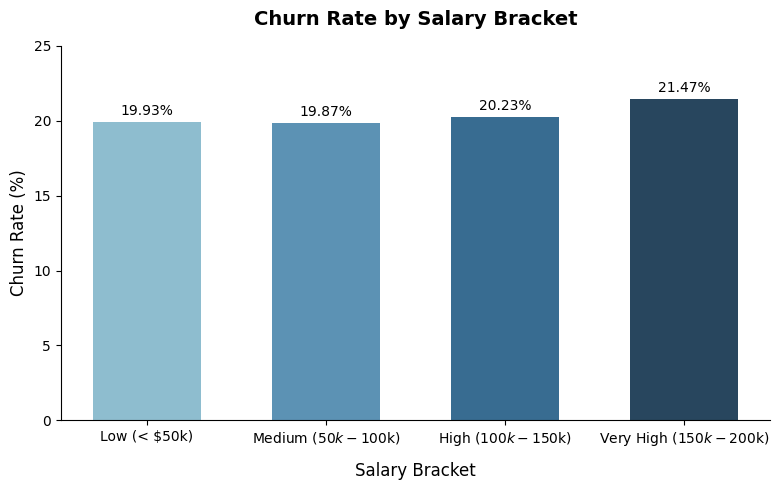

In [102]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#8ebdcf', '#5c92b4', '#386c91', '#28465e']
bars = ax.bar(
    salary_analysis['Salary_Slab'],
    salary_analysis['Churn_Rate'],
    color=colors,
    width=0.6,
)

# Set labels and title
ax.set_title(
    'Churn Rate by Salary Bracket', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Salary Bracket', fontsize=12, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 25)

# Add value labels on top of each bar
for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=10,
  )

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 13) How does the Churn Rate differ between high credit score individuals (>700) and low credit score individuals (<600)?

In [103]:
high_credit = df[df['CreditScore']>700]
low_credit = df[df['CreditScore']<600]
mid_credit = df[(df['CreditScore']>=600) & (df['CreditScore']<=700)]

high_stats = {
    'Category' : 'High Credit Score (>700)',
    'Total_Customers' : len(high_credit),
    'Exited_Customers':high_credit['Exited'].sum(),
    'Churn_Rate' : (high_credit['Exited'].mean() *100)
}

low_stats = {
    'Category' : 'Low Credit Score (<600)',
    'Total_Customers' : len(low_credit),
    'Exited_Customers':low_credit['Exited'].sum(),
    'Churn_Rate' : (low_credit['Exited'].mean() *100)
}

mid_stats = {
    'Category' : 'Mid Credit Score (600-700)',
    'Total_Customers' : len(mid_credit),
    'Exited_Customers':mid_credit['Exited'].sum(),
    'Churn_Rate' : (mid_credit['Exited'].mean() *100)
}

results_df = pd.DataFrame([low_stats,mid_stats,high_stats])
print(results_df)

                     Category  Total_Customers  Exited_Customers  Churn_Rate
0     Low Credit Score (<600)             3034               660   21.753461
1  Mid Credit Score (600-700)             3850               758   19.688312
2    High Credit Score (>700)             3116               619   19.865212


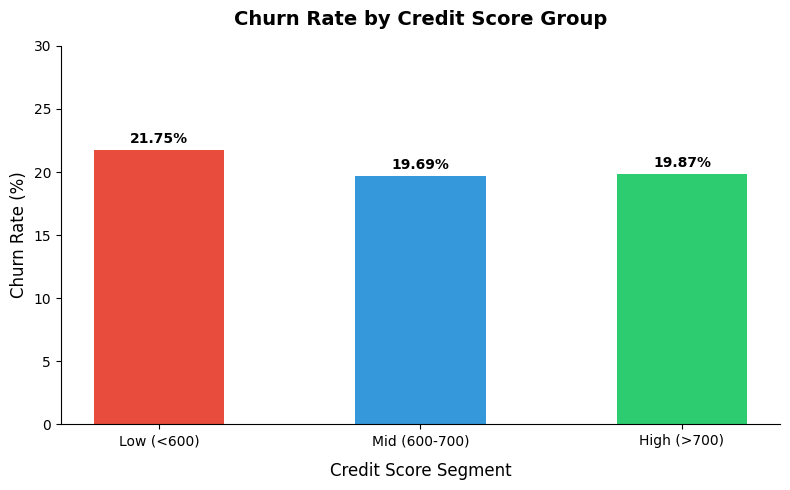

In [105]:
# Segment data by Credit Score
low_credit = df[df['CreditScore'] < 600]
mid_credit = df[(df['CreditScore'] >= 600) & (df['CreditScore'] <= 700)]
high_credit = df[df['CreditScore'] > 700]

categories = ['Low (<600)', 'Mid (600-700)', 'High (>700)']
churn_rates = [
    low_credit['Exited'].mean() * 100,
    mid_credit['Exited'].mean() * 100,
    high_credit['Exited'].mean() * 100,
]

# Plotting using Matplotlib
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = ax.bar(categories, churn_rates, color=colors, width=0.5)

ax.set_title(
    'Churn Rate by Credit Score Group', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Credit Score Segment', fontsize=12, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 30)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 14) What is the total financial loss (total balance lost) attributed to churned individuals?

In [109]:
total_balance_all = df['Balance'].sum()
churned_df = df[df['Exited'] == 1]
retained_df = df[df['Exited'] == 0]

total_loss = churned_df['Balance'].sum()
retained_balance = retained_df['Balance'].sum()
loss_percentage = (total_loss / total_balance_all) * 100

print(f"Total Balance All Customers: {total_balance_all:,.2f}")
print(f"Total Balance Retained Customers: {retained_balance:,.2f}")
print(f"Total Financial Loss (Churned Balance): {total_loss:,.2f}")
print(f"Percentage of Total Balance Lost: {loss_percentage:.2f}%")
print(f"Average Balance of Churned Customers: {churned_df['Balance'].mean():,.2f}")
print(f"Average Balance of Retained Customers: {retained_df['Balance'].mean():,.2f}")

Total Balance All Customers: 764,858,892.88
Total Balance Retained Customers: 579,270,798.25
Total Financial Loss (Churned Balance): 185,588,094.63
Percentage of Total Balance Lost: 24.26%
Average Balance of Churned Customers: 91,108.54
Average Balance of Retained Customers: 72,745.30


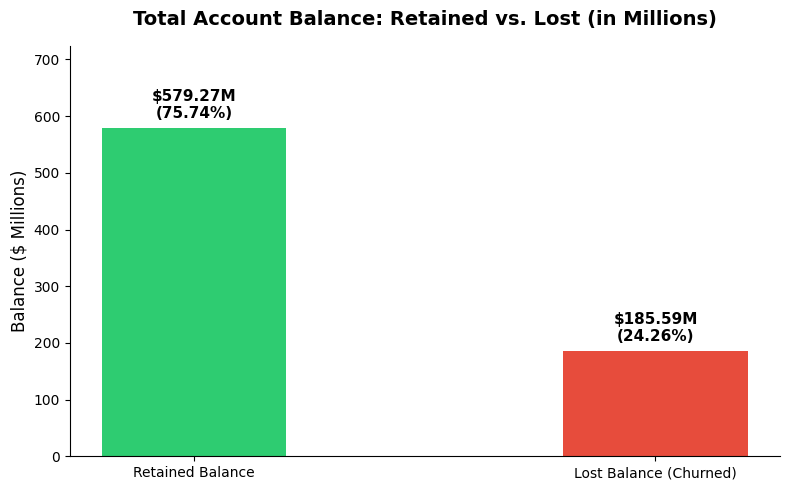

In [110]:
# Plotting using Matplotlib
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['Retained Balance', 'Lost Balance (Churned)']
balances_in_millions = [retained_balance / 1e6, total_loss / 1e6]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(categories, balances_in_millions, color=colors, width=0.4)

ax.set_title(
    'Total Account Balance: Retained vs. Lost (in Millions)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_ylabel('Balance ($ Millions)', fontsize=12)
ax.set_ylim(0, max(balances_in_millions) * 1.25)

# Annotate bars with values and percentages
for bar in bars:
  height = bar.get_height()
  actual_val = height * 1e6
  pct = (actual_val / total_balance_all) * 100
  ax.annotate(
      f'${height:.2f}M\n({pct:.2f}%)',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 15) What is the average CreditScore for churned versus retained members?

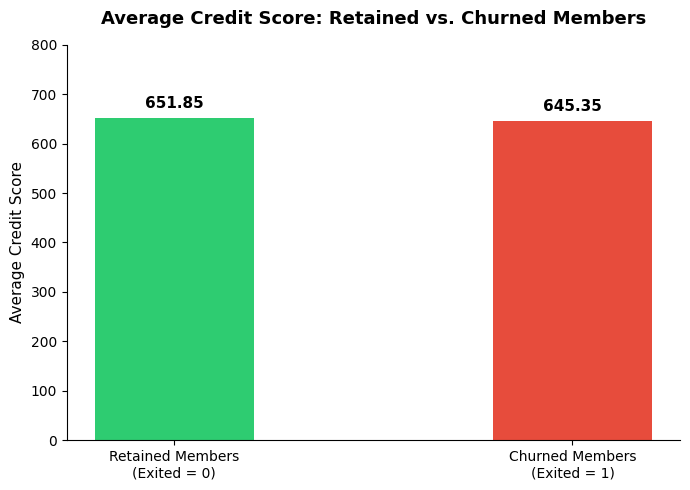

In [111]:
# Calculate mean credit scores
mean_retained = df[df['Exited'] == 0]['CreditScore'].mean()
mean_churned = df[df['Exited'] == 1]['CreditScore'].mean()

# Plotting using Matplotlib
fig, ax = plt.subplots(figsize=(7, 5))

categories = [
    'Retained Members\n(Exited = 0)',
    'Churned Members\n(Exited = 1)',
]
means = [mean_retained, mean_churned]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(categories, means, color=colors, width=0.4)

ax.set_title(
    'Average Credit Score: Retained vs. Churned Members',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
ax.set_ylabel('Average Credit Score', fontsize=11)
ax.set_ylim(0, 800)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Engagement & Tenure Insights

### 16) How does Tenure (number of years with the organization/bank) affect the Churn Rate?

In [117]:
tenure_analysis = df.groupby('Tenure').agg(
    Total_Customers = ('Exited', 'count'),
    Exited_Customers = ('Exited' ,'sum'),
    Churn_Rate = ('Exited' , 'mean')
).reset_index()

tenure_analysis['Churn_Rate_Pct'] = tenure_analysis['Churn_Rate'] * 100

print(tenure_analysis)


    Tenure  Total_Customers  Exited_Customers  Churn_Rate  Churn_Rate_Pct
0        0              413                95    0.230024       23.002421
1        1             1035               232    0.224155       22.415459
2        2             1048               201    0.191794       19.179389
3        3             1009               213    0.211100       21.110010
4        4              989               203    0.205258       20.525784
5        5             1012               209    0.206522       20.652174
6        6              967               196    0.202689       20.268873
7        7             1028               177    0.172179       17.217899
8        8             1025               197    0.192195       19.219512
9        9              984               213    0.216463       21.646341
10      10              490               101    0.206122       20.612245


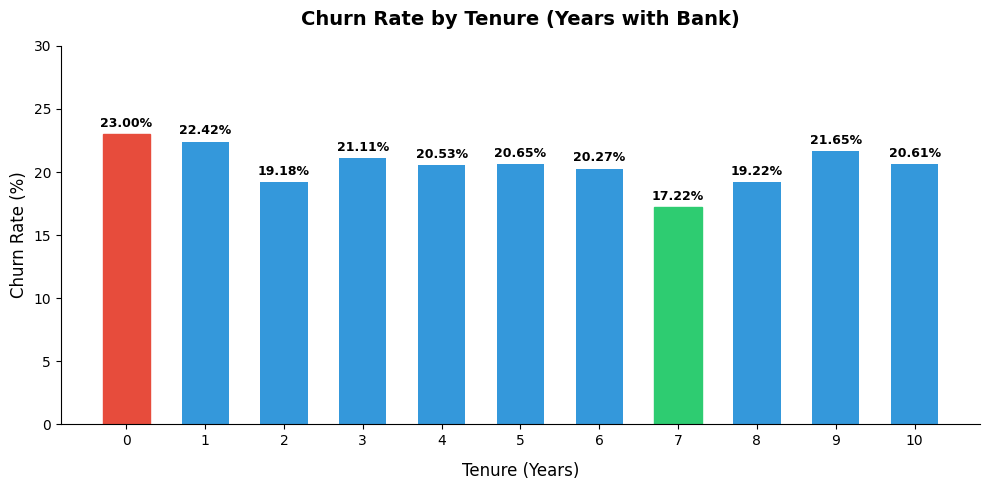

In [118]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    tenure_analysis['Tenure'],
    tenure_analysis['Churn_Rate_Pct'],
    color='#3498db',
    width=0.6,
)

# Highlight max (Tenure 0) and min (Tenure 7)
bars[0].set_color('#e74c3c')  # Red for highest churn
bars[7].set_color('#2ecc71')  # Green for lowest churn

ax.set_title(
    'Churn Rate by Tenure (Years with Bank)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Tenure (Years)', fontsize=12, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 30)
ax.set_xticks(tenure_analysis['Tenure'])

# Annotate bars
for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 17) Analyze the relationship between the number of products used (NumOfProducts) and the Churn Rate.

In [119]:
product_analysis = df.groupby('NumOfProducts').agg(
    Total_Customers=('Exited', 'count'),
    Exited_Customers=('Exited', 'sum'),
    Churn_Rate=('Exited', 'mean')
).reset_index()

product_analysis['Churn_Rate_Pct'] = product_analysis['Churn_Rate'] * 100

print(product_analysis)

   NumOfProducts  Total_Customers  Exited_Customers  Churn_Rate  \
0              1             5084              1409    0.277144   
1              2             4590               348    0.075817   
2              3              266               220    0.827068   
3              4               60                60    1.000000   

   Churn_Rate_Pct  
0       27.714398  
1        7.581699  
2       82.706767  
3      100.000000  


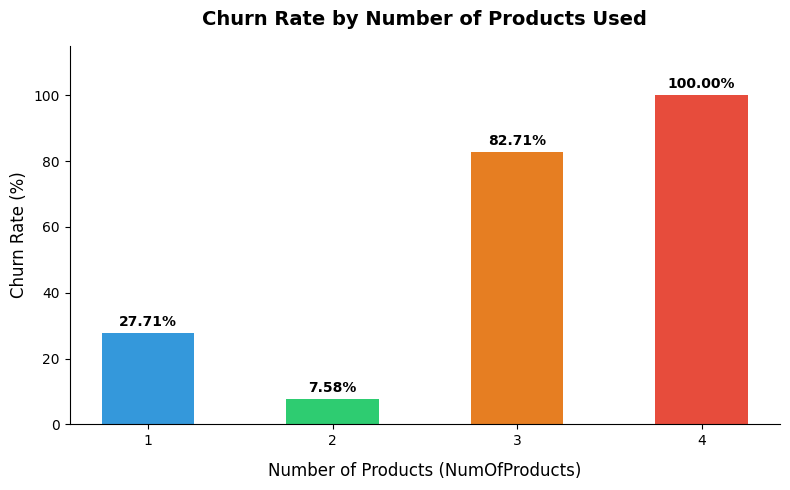

In [120]:
# Plotting using Matplotlib
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
bars = ax.bar(
    product_analysis['NumOfProducts'].astype(str),
    product_analysis['Churn_Rate_Pct'],
    color=colors,
    width=0.5,
)

ax.set_title(
    'Churn Rate by Number of Products Used',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Number of Products (NumOfProducts)', fontsize=12, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 115)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 18) Does owning a credit card (HasCrCard = 1) significantly influence the likelihood of exit?

In [122]:
crcard_analysis = df.groupby('HasCrCard').agg(
    Total_Customers=('Exited', 'count'),
    Exited_Customers=('Exited', 'sum'),
    Churn_Rate=('Exited', 'mean')
).reset_index()

crcard_analysis['Churn_Rate_Pct'] = crcard_analysis['Churn_Rate'] * 100

print(crcard_analysis)

   HasCrCard  Total_Customers  Exited_Customers  Churn_Rate  Churn_Rate_Pct
0          0             2945               613    0.208149       20.814941
1          1             7055              1424    0.201843       20.184266


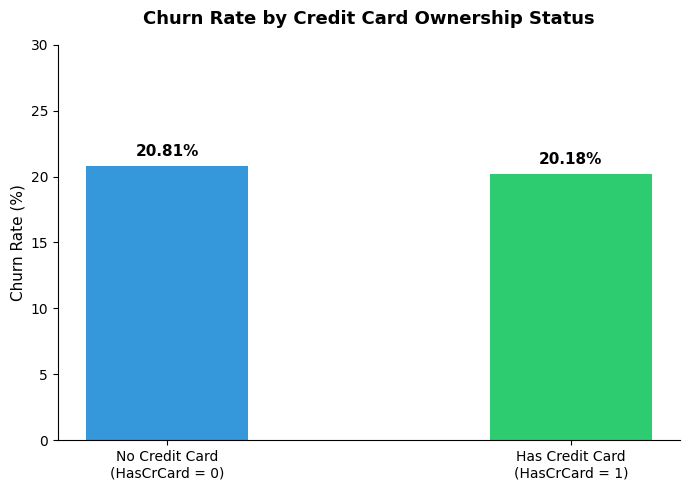

In [123]:
fig, ax = plt.subplots(figsize=(7, 5))

categories = [
    'No Credit Card\n(HasCrCard = 0)',
    'Has Credit Card\n(HasCrCard = 1)',
]
churn_rates = crcard_analysis['Churn_Rate_Pct'].tolist()
colors = ['#3498db', '#2ecc71']

bars = ax.bar(categories, churn_rates, color=colors, width=0.4)

ax.set_title(
    'Churn Rate by Credit Card Ownership Status',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 30)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 19) What percentage of individuals holding 3 or 4 products have exited?

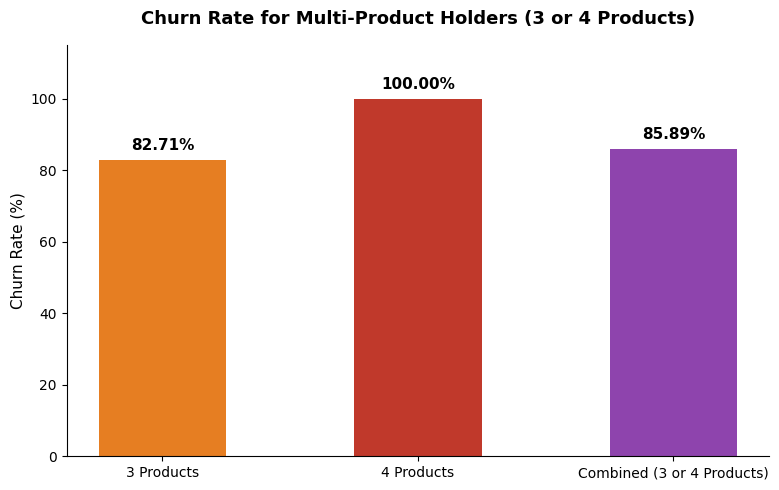

In [127]:
# Calculate metrics for 3 or 4 products
multi_prod = df[df['NumOfProducts'].isin([3, 4])]
total_multi = len(multi_prod)
exited_multi = multi_prod['Exited'].sum()
combined_rate = (exited_multi / total_multi) * 100


rate_3 = df[df['NumOfProducts'] == 3]['Exited'].mean() * 100
rate_4 = df[df['NumOfProducts'] == 4]['Exited'].mean() * 100
# Plotting using Matplotlib
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['3 Products', '4 Products', 'Combined (3 or 4 Products)']
rates = [rate_3, rate_4, combined_rate]
colors = ['#e67e22', '#c0392b', '#8e44ad']

bars = ax.bar(categories, rates, color=colors, width=0.5)

ax.set_title(
    'Churn Rate for Multi-Product Holders (3 or 4 Products)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 115)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 20) Identify individuals who have a high tenure (e.g., >8 years) but are currently marked as inactive (IsActiveMember = 0).

In [129]:
# High tenure (>8 years) and inactive (IsActiveMember == 0)
high_tenure_inactive = df[(df['Tenure'] > 8) & (df['IsActiveMember'] == 0)]

print(f"Total count: {len(high_tenure_inactive)}")
print(f"Total dataset size: {len(df)}")
print(f"Percentage of total customers: {(len(high_tenure_inactive) / len(df)) * 100:.2f}%")

# Churn rate within this specific segment
churn_rate_segment = high_tenure_inactive['Exited'].mean() * 100
print(f"Churn rate in this high-tenure inactive group: {churn_rate_segment:.2f}%")

# Preview top 10 rows
columns_to_show = ['CustomerId', 'Surname', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited']
print(high_tenure_inactive[columns_to_show].head(10).to_string(index=False))

Total count: 754
Total dataset size: 10000
Percentage of total customers: 7.54%
Churn rate in this high-tenure inactive group: 28.51%
 CustomerId    Surname Geography Gender  Age  Tenure   Balance  NumOfProducts  IsActiveMember  Exited
   15632264        Kay    France Female   34      10      0.00              2               0       0
   15700772    Nebechi    France   Male   44       9      0.00              2               0       0
   15750181  Sanderson   Germany   Male   41       9 110112.54              2               0       0
   15616550 Chidiebele   Germany   Male   44      10 116363.37              2               0       0
   15773469      Clark   Germany Female   27       9 152328.88              2               0       0
   15803136     Postle   Germany Female   41      10 122189.66              2               0       0
   15625759     Rowley    France   Male   30       9      0.00              2               0       0
   15809248       Cole    France Female   36      

In [130]:
# Summary metrics
tenure_breakdown = high_tenure_inactive.groupby('Tenure').agg(
    Total=('Exited', 'count'),
    Exited=('Exited', 'sum'),
    Churn_Rate=('Exited', 'mean')
).reset_index()

tenure_breakdown['Churn_Rate_Pct'] = tenure_breakdown['Churn_Rate'] * 100

print(tenure_breakdown)

   Tenure  Total  Exited  Churn_Rate  Churn_Rate_Pct
0       9    513     150    0.292398       29.239766
1      10    241      65    0.269710       26.970954


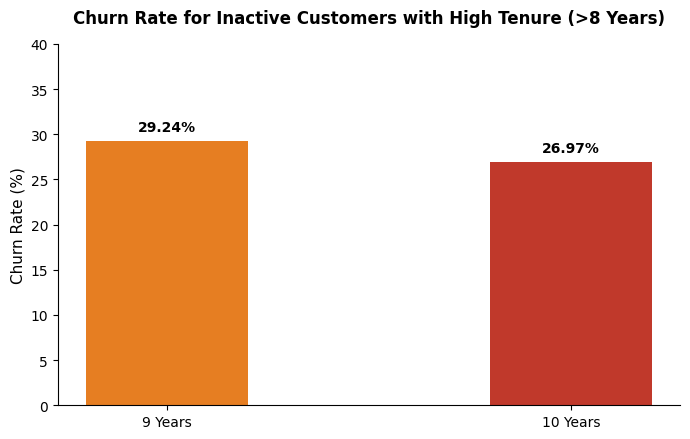

In [132]:
# Plot breakdown by tenure 9 and 10
fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(tenure_breakdown['Tenure'].astype(str) + ' Years', 
              tenure_breakdown['Churn_Rate_Pct'], 
              color=['#e67e22', '#c0392b'], width=0.4)

ax.set_title('Churn Rate for Inactive Customers with High Tenure (>8 Years)', fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 40)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('high_tenure_inactive.png', dpi=300)
plt.show()

# Advanced Cross-Tabulation & Grouping

### 21) Perform a cross-tabulation analysis of Geography and Gender to compare churn percentages across combinations.

In [135]:
ct_summary = df.groupby(['Geography', 'Gender']).agg(
    Total_Customers=('Exited', 'count'),
    Exited_Customers=('Exited', 'sum'),
    Churn_Rate=('Exited', 'mean')
).reset_index()

ct_summary['Churn_Rate_Pct'] = ct_summary['Churn_Rate'] * 100

print(ct_summary)

# Crosstab table for Churn Rate Pct matrix
crosstab_pct = pd.crosstab(df['Geography'], df['Gender'], values=df['Exited'], aggfunc='mean') * 100
print("\nChurn Rate (%) Crosstab Matrix:")
print(crosstab_pct)

  Geography  Gender  Total_Customers  Exited_Customers  Churn_Rate  \
0    France  Female             2261               460    0.203450   
1    France    Male             2753               350    0.127134   
2   Germany  Female             1193               448    0.375524   
3   Germany    Male             1316               366    0.278116   
4     Spain  Female             1089               231    0.212121   
5     Spain    Male             1388               182    0.131124   

   Churn_Rate_Pct  
0       20.344980  
1       12.713404  
2       37.552389  
3       27.811550  
4       21.212121  
5       13.112392  

Churn Rate (%) Crosstab Matrix:
Gender        Female       Male
Geography                      
France     20.344980  12.713404
Germany    37.552389  27.811550
Spain      21.212121  13.112392


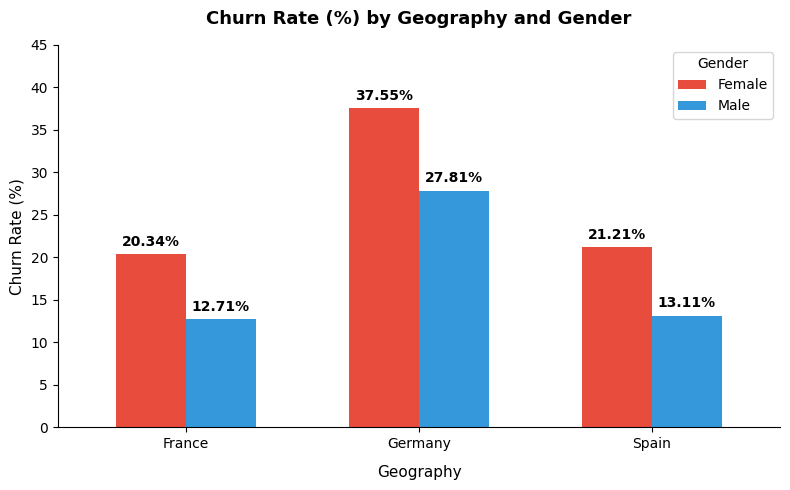

In [136]:
# Pivot data for grouped bar chart
pivot_df = ct_summary.pivot(
    index='Geography', columns='Gender', values='Churn_Rate_Pct'
)

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
pivot_df.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'], width=0.6)

ax.set_title(
    'Churn Rate (%) by Geography and Gender',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Geography', fontsize=11, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 45)
ax.legend(title='Gender', frameon=True)

for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{height:.2f}%',
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 22) Identify the top 10 individuals with the highest account balance and check their exit status.

In [137]:
# Sort by Balance descending and pick top 10
top10_balance = df.sort_values(by='Balance', ascending=False).head(10)

columns_to_show = ['CustomerId', 'Surname', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited']
top10_display = top10_balance[columns_to_show].copy()

# Add a readable Status column
top10_display['Exit_Status'] = top10_display['Exited'].map({0: 'Retained (0)', 1: 'Exited (1)'})

print(top10_display.to_string(index=False))

# Calculate churn rate among top 10 balance holders
top10_churn_count = top10_display['Exited'].sum()
top10_churn_rate = top10_display['Exited'].mean() * 100
print(f"\nExited count in top 10: {top10_churn_count}/10")
print(f"Churn rate in top 10: {top10_churn_rate:.1f}%")

 CustomerId  Surname Geography Gender  Age  Tenure   Balance  NumOfProducts  IsActiveMember  Exited  Exit_Status
   15757408       Lo     Spain   Male   38       3 250898.09              3               1       1   Exited (1)
   15715622   To Rot    France Female   57       3 238387.56              1               1       1   Exited (1)
   15714241   Haddon     Spain   Male   42       9 222267.63              1               0       1   Exited (1)
   15571958 McIntosh     Spain   Male   40       3 221532.80              1               0       0 Retained (0)
   15586674     Shaw     Spain Female   58       5 216109.88              1               1       1   Exited (1)
   15599131    Dilke   Germany   Male   26       4 214346.96              2               0       0 Retained (0)
   15594408     Chia     Spain Female   48       2 213146.20              1               0       1   Exited (1)
   15769818    Moore    France Female   37       3 212778.20              1               1     

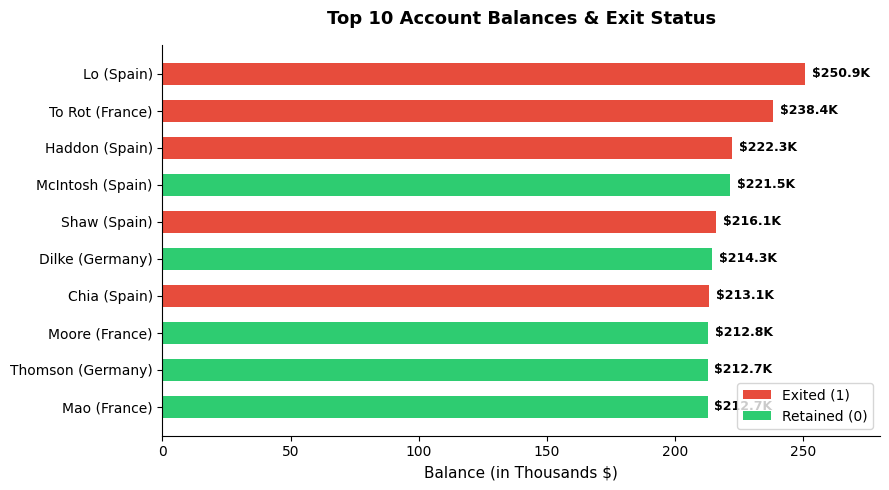

In [139]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

top10_sorted = top10_display.sort_values(by='Balance', ascending=True)

colors = ['#e74c3c' if exit == 1 else '#2ecc71' for exit in top10_sorted['Exited']]
bars = ax.barh(top10_sorted['Surname'] + ' (' + top10_sorted['Geography'] + ')', top10_sorted['Balance'] / 1000, color=colors, height=0.6)

ax.set_title('Top 10 Account Balances & Exit Status', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Balance (in Thousands $)', fontsize=11)
ax.set_xlim(0, 280)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Exited (1)'),
    Patch(facecolor='#2ecc71', label='Retained (0)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'${width:.1f}K',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=9, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('top10_balance_exit_status.png', dpi=300)
plt.show()

### 23) Create age categories (e.g., <30, 30–45, 45–60, 60+) and find the churn rate within each age bracket.

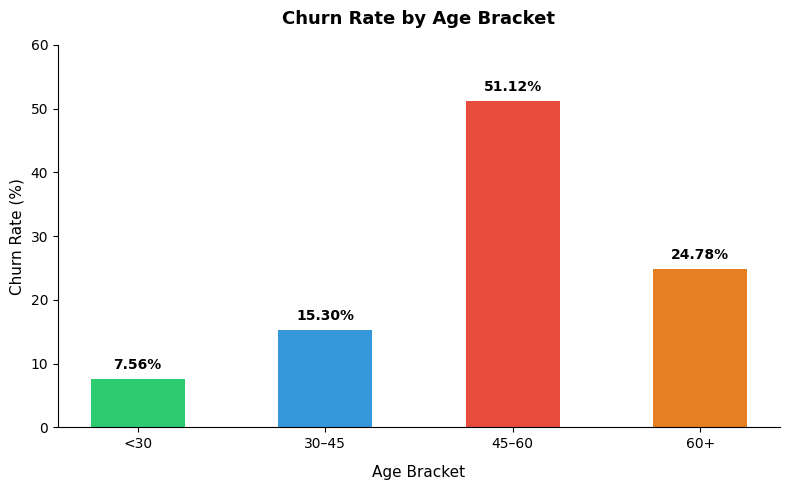

In [141]:
# Categorize into age brackets
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[-1, 29, 45, 60, 200],
    labels=['<30', '30–45', '45–60', '60+'],
)

# Aggregate churn metrics
age_analysis = (
    df.groupby('AgeGroup', observed=False)
    .agg(
        Total_Customers=('Exited', 'count'),
        Exited_Customers=('Exited', 'sum'),
        Churn_Rate=('Exited', 'mean'),
    )
    .reset_index()
)

age_analysis['Churn_Rate_Pct'] = age_analysis['Churn_Rate'] * 100

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22']
bars = ax.bar(
    age_analysis['AgeGroup'].astype(str),
    age_analysis['Churn_Rate_Pct'],
    color=colors,
    width=0.5,
)

ax.set_title('Churn Rate by Age Bracket', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Age Bracket', fontsize=11, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 60)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 24) Find the count and churn rate of individuals who have a low credit score (<600) and zero balance (Balance = 0).

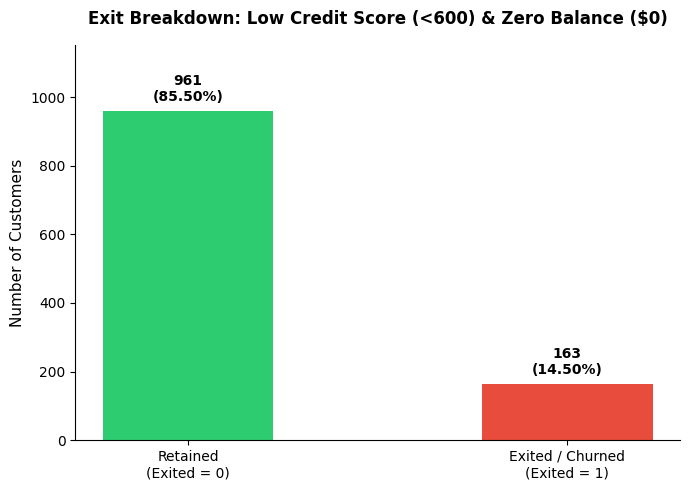

In [143]:
# Filter low credit score (<600) and zero balance
subset = df[(df['CreditScore'] < 600) & (df['Balance'] == 0)]

total_count = len(subset)
exited_count = int(subset['Exited'].sum())
retained_count = total_count - exited_count
churn_rate = subset['Exited'].mean() * 100

# Plotting
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['Retained\n(Exited = 0)', 'Exited / Churned\n(Exited = 1)']
counts = [retained_count, exited_count]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(categories, counts, color=colors, width=0.45)

ax.set_title(
    'Exit Breakdown: Low Credit Score (<600) & Zero Balance ($0)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_ylim(0, max(counts) * 1.2)

for bar in bars:
  height = bar.get_height()
  pct = (height / total_count) * 100
  ax.annotate(
      f'{height:,}\n({pct:.2f}%)',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 25) Engineer a new feature representing the Balance-to-Salary Ratio and check its correlation with churn.

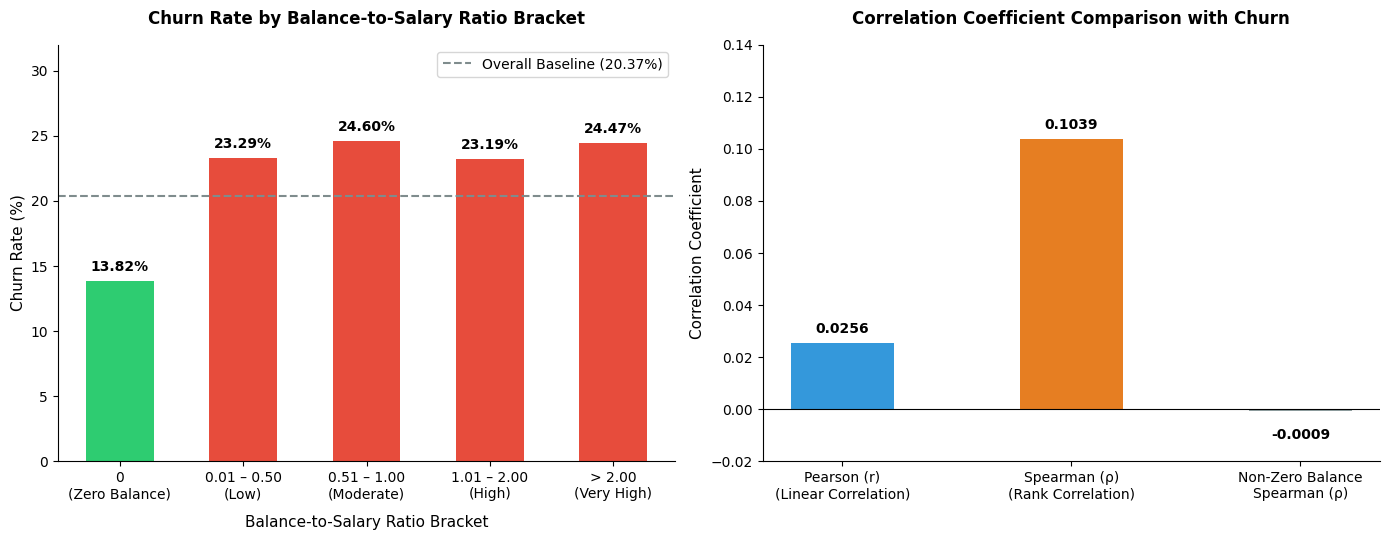

In [144]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Load dataset
df = pd.read_csv('Bank_Churn.csv')

# Feature engineering: Balance-to-Salary Ratio
df['BalanceToSalaryRatio'] = df['Balance'] / df['EstimatedSalary']

# Calculate correlations
pearson_r, _ = stats.pearsonr(df['BalanceToSalaryRatio'], df['Exited'])
spearman_p, _ = stats.spearmanr(df['BalanceToSalaryRatio'], df['Exited'])

df_nonzero = df[df['Balance'] > 0]
spearman_nonzero, _ = stats.spearmanr(
    df_nonzero['BalanceToSalaryRatio'], df_nonzero['Exited']
)

# Categorize into ratio brackets
df['Ratio_Category'] = pd.cut(
    df['BalanceToSalaryRatio'],
    bins=[-0.01, 0, 0.5, 1.0, 2.0, np.inf],
    labels=[
        '0\n(Zero Balance)',
        '0.01 – 0.50\n(Low)',
        '0.51 – 1.00\n(Moderate)',
        '1.01 – 2.00\n(High)',
        '> 2.00\n(Very High)',
    ],
)

ratio_binned = (
    df.groupby('Ratio_Category', observed=False)
    .agg(
        Total_Customers=('Exited', 'count'),
        Exited_Customers=('Exited', 'sum'),
        Churn_Rate=('Exited', 'mean'),
    )
    .reset_index()
)

ratio_binned['Churn_Rate_Pct'] = ratio_binned['Churn_Rate'] * 100

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: Churn Rate by Ratio Bracket
categories = ratio_binned['Ratio_Category'].astype(str).tolist()
churn_rates = ratio_binned['Churn_Rate_Pct'].tolist()
colors = ['#2ecc71' if i == 0 else '#e74c3c' for i in range(len(categories))]

bars1 = ax1.bar(categories, churn_rates, color=colors, width=0.55)
ax1.axhline(
    df['Exited'].mean() * 100,
    color='#7f8c8d',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall Baseline ({df["Exited"].mean()*100:.2f}%)',
)

ax1.set_title(
    'Churn Rate by Balance-to-Salary Ratio Bracket',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
ax1.set_xlabel('Balance-to-Salary Ratio Bracket', fontsize=11, labelpad=10)
ax1.set_ylabel('Churn Rate (%)', fontsize=11)
ax1.set_ylim(0, 32)
ax1.legend(loc='upper right')

for bar in bars1:
  height = bar.get_height()
  ax1.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

# Subplot 2: Correlation Comparison
corr_labels = [
    'Pearson (r)\n(Linear Correlation)',
    'Spearman (ρ)\n(Rank Correlation)',
    'Non-Zero Balance\nSpearman (ρ)',
]
corr_values = [pearson_r, spearman_p, spearman_nonzero]
corr_colors = ['#3498db', '#e67e22', '#95a5a6']

bars2 = ax2.bar(corr_labels, corr_values, color=corr_colors, width=0.45)
ax2.axhline(0, color='black', linewidth=0.8)

ax2.set_title(
    'Correlation Coefficient Comparison with Churn',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
ax2.set_ylabel('Correlation Coefficient', fontsize=11)
ax2.set_ylim(-0.02, 0.14)

for bar in bars2:
  height = bar.get_height()
  va = 'bottom' if height >= 0 else 'top'
  xytext = (0, 5) if height >= 0 else (0, -12)
  ax2.annotate(
      f'{height:.4f}',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=xytext,
      textcoords='offset points',
      ha='center',
      va=va,
      fontsize=10,
      fontweight='bold',
  )

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Correlation & Data Visualization

### 26) Generate a Correlation Heatmap for all numerical variables and identify which feature correlates most strongly with Exited.

In [146]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'RowNumber' in num_cols:
    num_cols.remove('RowNumber')
if 'CustomerId' in num_cols:
    num_cols.remove('CustomerId')

corr_matrix = df[num_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

print('\nCorrelations with Exited (sorted):')
print(corr_matrix['Exited'].sort_values(ascending=False))

Correlation Matrix:
                      CreditScore       Age    Tenure   Balance  \
CreditScore              1.000000 -0.003965  0.000842  0.006268   
Age                     -0.003965  1.000000 -0.009997  0.028308   
Tenure                   0.000842 -0.009997  1.000000 -0.012254   
Balance                  0.006268  0.028308 -0.012254  1.000000   
NumOfProducts            0.012238 -0.030680  0.013444 -0.304180   
HasCrCard               -0.005458 -0.011721  0.022583 -0.014858   
IsActiveMember           0.025651  0.085472 -0.028362 -0.010084   
EstimatedSalary         -0.001384 -0.007201  0.007784  0.012797   
Exited                  -0.027094  0.285323 -0.014001  0.118533   
BalanceToSalaryRatio     0.006652  0.008837 -0.000230  0.027235   

                      NumOfProducts  HasCrCard  IsActiveMember  \
CreditScore                0.012238  -0.005458        0.025651   
Age                       -0.030680  -0.011721        0.085472   
Tenure                     0.013444   0.0225

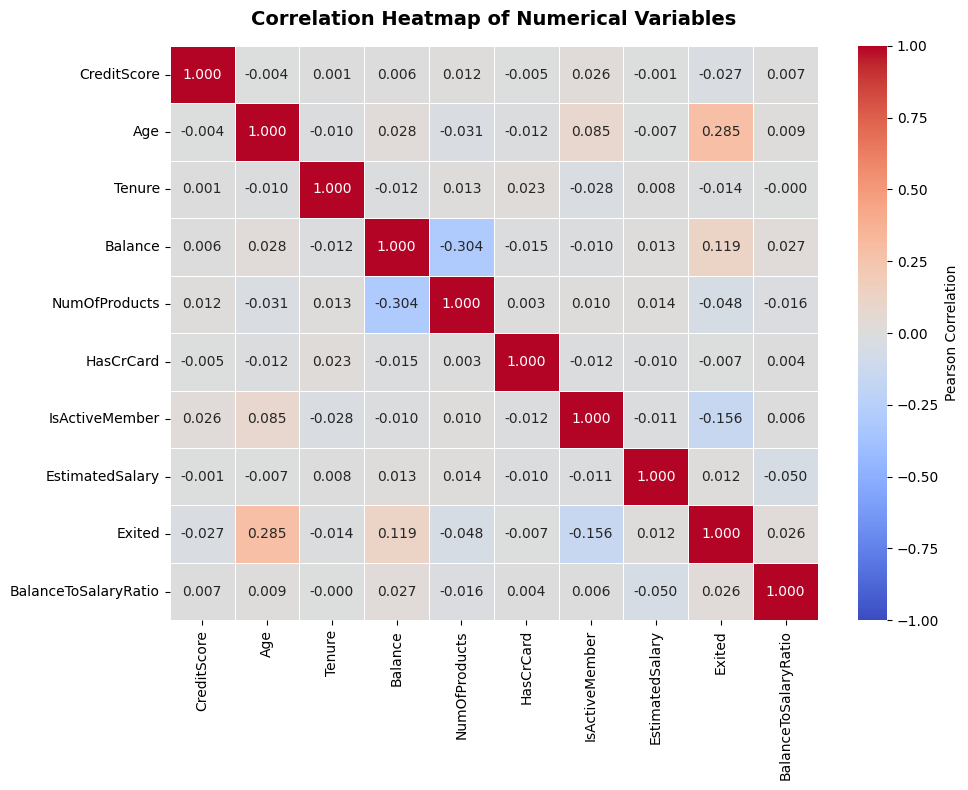

In [148]:
# Plot Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            cbar_kws={'label':'Pearson Correlation'}
           )

plt.title('Correlation Heatmap of Numerical Variables',
          fontsize=14,
          fontweight='bold',
          pad=15
         )
plt.tight_layout()
plt.show()          

### 27) Plot a Scatter Plot of Age vs Balance, using Exited as a color hue.

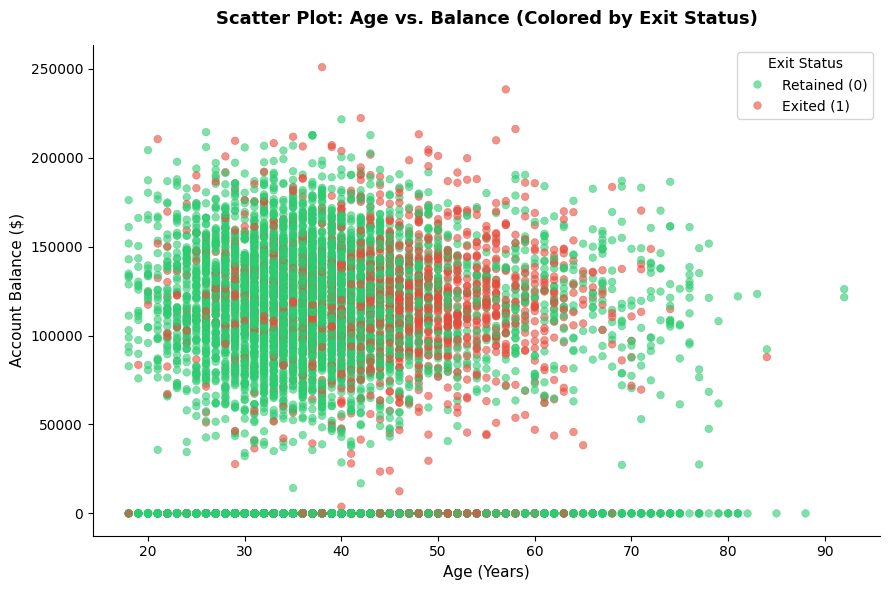

In [150]:
fig, ax = plt.subplots(figsize=(9,6))

scatter = sns.scatterplot(
    data = df,
    x = 'Age',
    y = 'Balance',
    hue = 'Exited',
    palette = {0: '#2ecc71',1:'#e74c3c'},
    alpha=0.6,
    s=30,
    edgecolor=None,
    ax=ax
)

ax.set_title('Scatter Plot: Age vs. Balance (Colored by Exit Status)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Age (Years)', fontsize=11)
ax.set_ylabel('Account Balance ($)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Retained (0)', 'Exited (1)'], title='Exit Status', loc='upper right', frameon=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 28) Create a Bar Chart displaying the Total EstimatedSalary distributed by Geography.

  Geography           sum           mean  count  Total_Salary_Millions
0    France  5.008945e+08   99899.180814   5014             500.894493
1   Germany  2.536936e+08  101113.435102   2509             253.693609
2     Spain  2.463143e+08   99440.572281   2477             246.314298


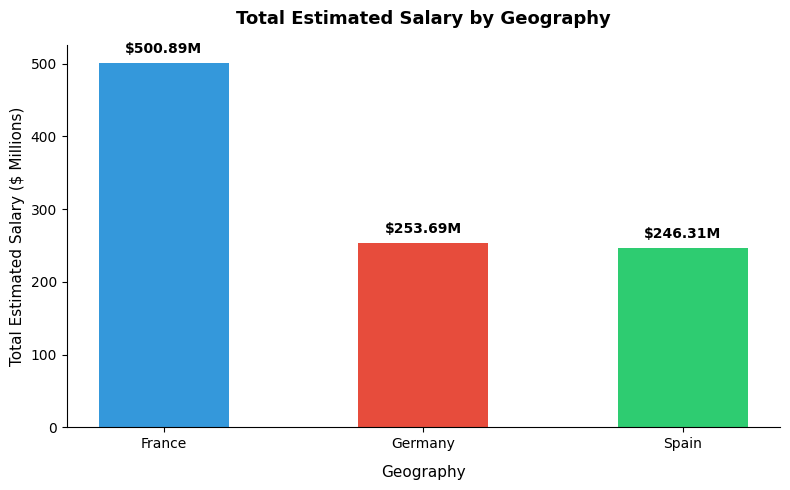

In [152]:
# Group by Geography and calculate sum and mean of EstimatedSalary
geo_salary = df.groupby('Geography')['EstimatedSalary'].agg(['sum', 'mean', 'count']).reset_index()
geo_salary['Total_Salary_Millions'] = geo_salary['sum'] / 1e6

print(geo_salary)

# Create Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(geo_salary['Geography'], geo_salary['Total_Salary_Millions'], color=['#3498db', '#e74c3c', '#2ecc71'], width=0.5)

ax.set_title('Total Estimated Salary by Geography', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Geography', fontsize=11, labelpad=10)
ax.set_ylabel('Total Estimated Salary ($ Millions)', fontsize=11)

# Annotate values
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'${height:.2f}M',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 29) Plot a KDE/Histogram distribution of CreditScore segmented by churn status.

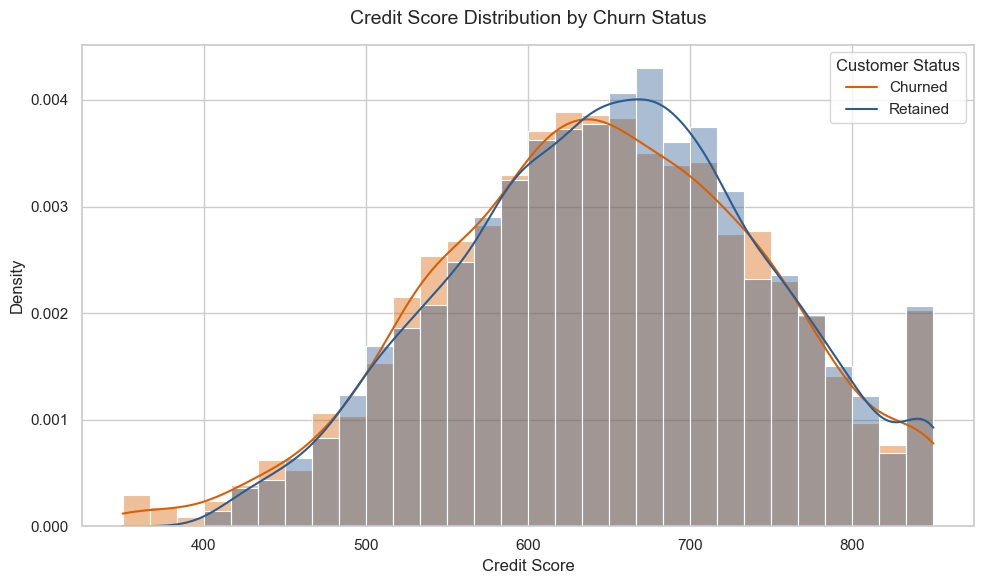

In [154]:
# Setup plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot KDE and Histogram split by Churn status
sns.histplot(
    data=df,
    x="CreditScore",
    hue="Exited",  # Replace with your churn column name if different (e.g., 'Churn')
    kde=True,
    stat="density",
    common_norm=False,
    bins=30,
    palette={0: "#2b5c8f", 1: "#d95f02"},  # Blue for Retained, Orange for Churned
    alpha=0.4,
    linewidth=0.8,
)

# Titles and Labels
plt.title("Credit Score Distribution by Churn Status", fontsize=14, pad=15)
plt.xlabel("Credit Score", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Customizing Legend Labels
plt.legend(title="Customer Status", labels=["Churned", "Retained"])

plt.tight_layout()
plt.show()

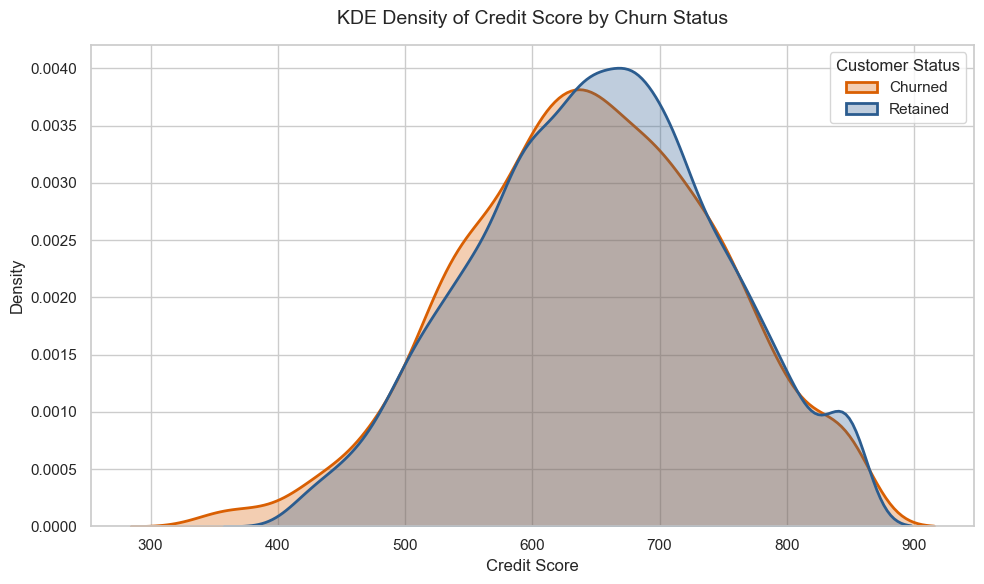

In [155]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="CreditScore",
    hue="Exited",
    fill=True,
    common_norm=False,
    palette={0: "#2b5c8f", 1: "#d95f02"},
    alpha=0.3,
    linewidth=2,
)

plt.title("KDE Density of Credit Score by Churn Status", fontsize=14, pad=15)
plt.xlabel("Credit Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Customer Status", labels=["Churned", "Retained"])

plt.tight_layout()
plt.show()

### 30) Create Boxplots for Age across different NumOfProducts categories to detect any outliers.

C:\Users\dell\AppData\Local\Temp\ipykernel_23368\769794419.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


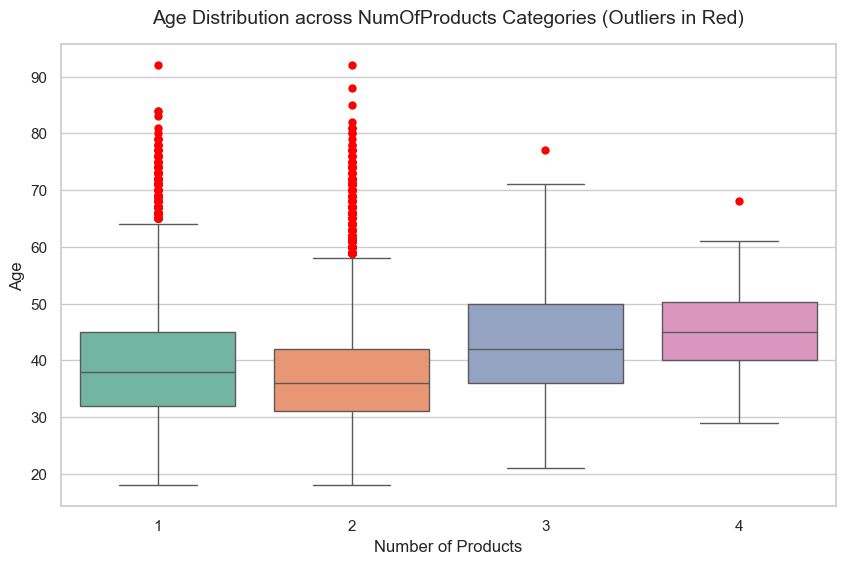

In [156]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create boxplot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    x="NumOfProducts",
    y="Age",
    data=df,
    palette="Set2",
    fliersize=5,  # Size of outlier points
    flierprops=dict(
        marker="o", markerfacecolor="red", markersize=6, markeredgecolor="none"
    ),
)

plt.title(
    "Age Distribution across NumOfProducts Categories (Outliers in Red)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Age", fontsize=12)

plt.show()